### <a name="f1"></a>**Function 1**
- **Inputs**: 2d array (10, 2)
- **Ouput**: 1d array (10,)
- **Goal**: Maximise - find the likely coordinates of contamination.
- **Description**: Detect likely contamination sources in a two-dimensional area, such as a radiation field, where **only proximity yields a non-zero reading**. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys
from IPython.display import display, Math, Latex

src = os.path.expanduser("~/repos/capstone_imperial_ml_ai/src")
if src not in sys.path:
    sys.path.append(src)

from ml.data import DataLoader, TransformUtils
from ml.plot import PlotUtils

import numpy as np


In [3]:
data = DataLoader.DATA['f1']
df = DataLoader.to_pandas(data=data)

In [4]:
df.describe()

,X_0,X_1,y
count,13.000000,13.000000,1.300000e+01
mean,0.557257,0.593217,-1.882970e-03
std,0.227828,0.283310,3.941848e-03
min,0.082507,0.078723,-1.136232e-02
25%,0.410437,0.403488,-2.159249e-54
50%,0.633372,0.681248,1.252746e-88
75%,0.683418,0.762959,6.229856e-48
max,0.883890,0.954131,7.710875e-16


In [5]:
X = data['X']
y = data['y']

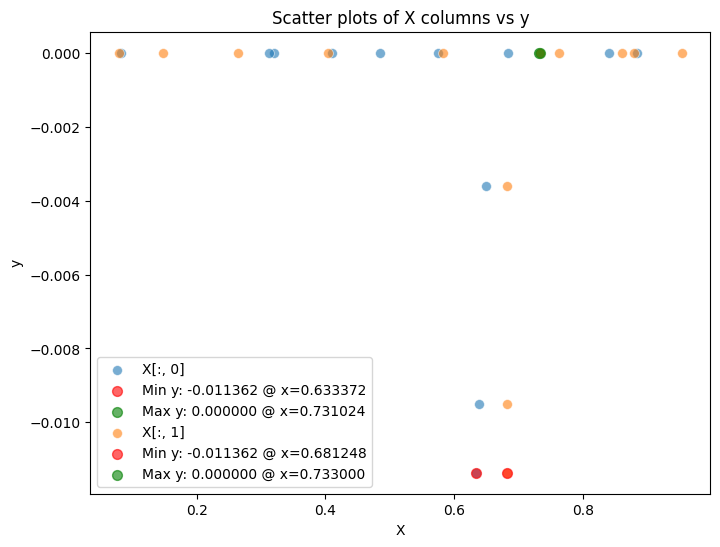

In [6]:
PlotUtils.scatter(X=X, y=y)

In [7]:
outlier_indices = TransformUtils.get_quantile_outliers(y)
print("Outlier indices:", outlier_indices)
print("Outlier values:", y[outlier_indices])
df['y_abs'] = df['y'].abs()
df.sort_values(by='y_abs', ascending=False).head(5)

Outlier indices: (array([ 1,  2,  4,  7, 11, 12]),)
Outlier values: [ 1.03307824e-46  7.71087511e-16 -3.60606264e-03  2.53500115e-40
 -9.51022887e-03 -1.13623227e-02]


,X_0,X_1,y,y_abs
12,0.633372,0.681248,-1.136232e-02,1.136232e-02
11,0.638372,0.681248,-9.510229e-03,9.510229e-03
4,0.650114,0.681526,-3.606063e-03,3.606063e-03
2,0.731024,0.733000,7.710875e-16,7.710875e-16
7,0.683418,0.861057,2.535001e-40,2.535001e-40


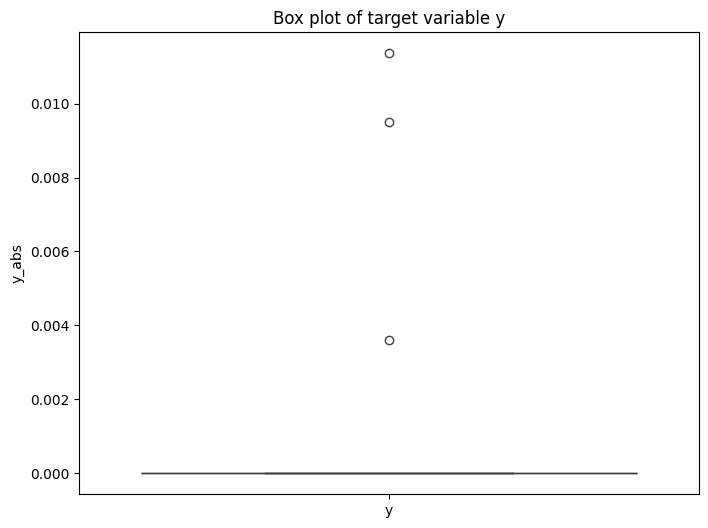

In [8]:
PlotUtils.box(data=df['y_abs'], title="Box plot of target variable y")

Using absolute value of `y` because we are interested in the magnitude. 

`y_abs` is furthest away from `0` where:
- `X_0` is in the range of `[0.630, 0.650]` and,
- `X_1` in the range `[0.681, 0.682]`

### Data
- Most values of `y` are very close to 0
- Using `IqR`, outliers are ~13 orders of magnitude away
- Transform data to absolute value and to log-scale


In [9]:
x_log = np.log(np.abs(X))
y_log = np.log(np.abs(y))

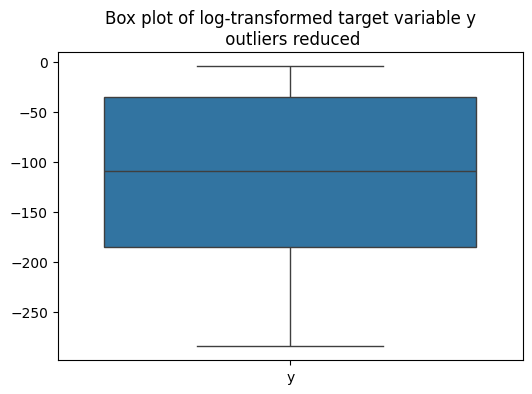

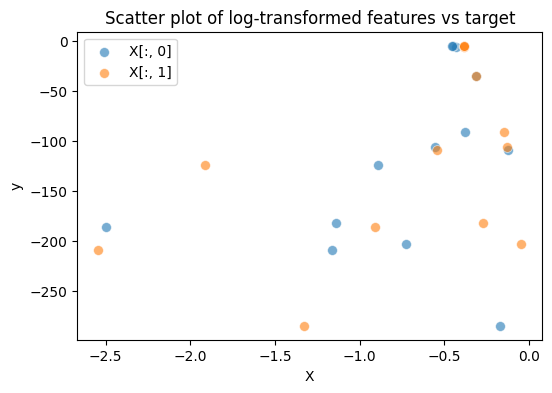

In [10]:
PlotUtils.box(data=y_log, figsize=(6,4), title="Box plot of log-transformed target variable y\n outliers reduced")
PlotUtils.scatter(X=x_log, y=y_log, figsize=(6,4), title="Scatter plot of log-transformed features vs target", show_min_max=False)

## Week1: Linear Model
The idea here is to find a linear model that best fits the data and the use Gradient Descent to minimise the value of the dependent variable.

1. Create polynomial features from the data.* 
2. Fit a LinearRegression model usign the polynomial features. 
3. Score the model using the negative MSE (mean squared error) 
4. Store the degree and MSE to compare against other polynomial degrees
5. Iterate for degrees 1 to 10
6. Stop when MSE is close to 0 - model fits the data almost exactly. 

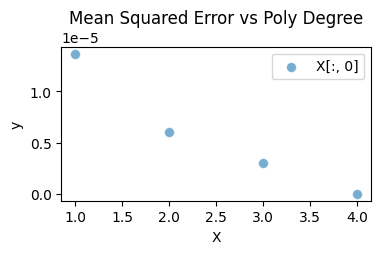

Best polynomial degree: 4, with MSE: 8.963200272446433e-28


In [18]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def find_best_degree(X, y, max_degree=10):
    best_degree = 1
    min_error = float('inf')
    avg_errors = []
    for degree in range(1, max_degree + 1):
        # Create polynomial features, excluding bias term (intercept)
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_poly = poly.fit_transform(X)
        
        # Use Cross-Validation to evaluate the degree
        model = LinearRegression()
        model.fit(X_poly, y)
        
        # Negative MSE as scoring
        scores = -1 * np.mean((model.predict(X_poly) - y) ** 2)
        avg_error = -scores
        avg_errors.append((degree, avg_error))

        if avg_error < min_error:
            min_error = avg_error
            best_degree = degree
        
        if np.isclose(avg_error, 0):
            break

    PlotUtils.scatter(np.array([e[0] for e in avg_errors]), np.array([e[1] for e in avg_errors]), title="Mean Squared Error vs Poly Degree", figsize=(4,2), show_min_max=False)
    return best_degree, min_error

best_degree, min_error = find_best_degree(X, y, max_degree=20)
print(f"Best polynomial degree: {best_degree}, with MSE: {min_error}")

Note that a polynomial of degree 4 fits the data almost exactly, the MSE is close to 0. 

### Create a Linear Model
Using the best degree polynomial, create a linear regression. Plot the predicted values of `ŷ` against the actual values of `y`.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


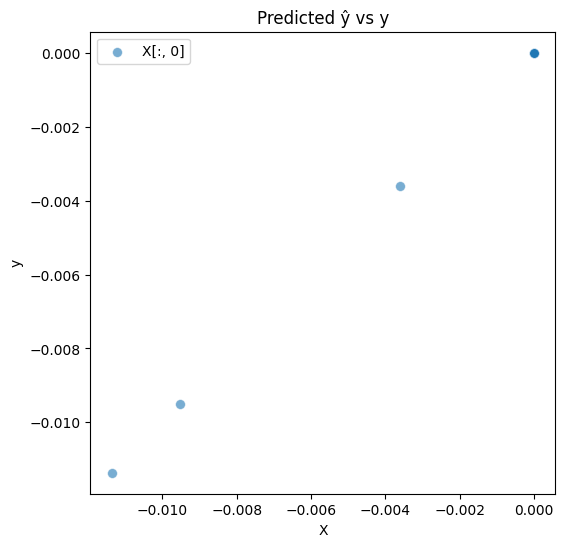

In [19]:
poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)
y_pred = model.predict(X_poly)

PlotUtils.scatter(y_pred, y, title="Predicted ŷ vs y", figsize=(6,6), show_min_max=False)

## Minimize 
This step is to find a set of values for `X_0` and `X_1` that minimise the function. 
1. Using the polynomial transform and the linear regression model, create an objective function that is the target for the minimisation.
2. Used scipy's package minimisation module.
3. Declare a starting point for the minimisation, `[0.68341817, 0.40348751]` which is close to the known minimum.

In [20]:
from scipy.optimize import minimize

# 1. Define your function (the fitted polynomial)
def objective_function(x):
    # We want to find the MAX, so we minimize the NEGATIVE
    x_poly = poly.transform(np.array([x]))
    return -model.predict(x_poly) 

# 2. Run the optimizer
# 'x0' is your starting guess
result = minimize(objective_function, x0=[0.68341817, 0.40348751], method='L-BFGS-B')

print(f"The minimum is at x = {result.x}")



The minimum is at x = [0.75175902 0.35916161]


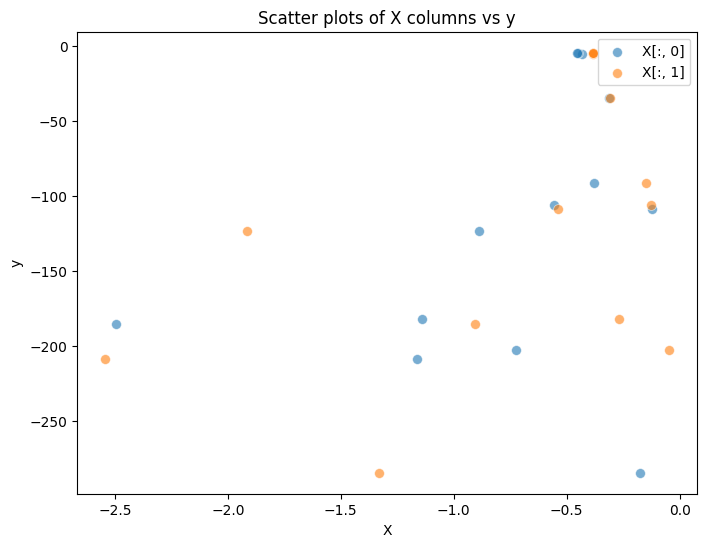

/tmp/ipykernel_15520/316005418.py:14: RuntimeWarning: invalid value encountered in log
  PlotUtils.scatter(np.log(X_transformed), np.log(y_transformed), show_min_max=False)
/tmp/ipykernel_15520/316005418.py:14: RuntimeWarning: divide by zero encountered in log
  PlotUtils.scatter(np.log(X_transformed), np.log(y_transformed), show_min_max=False)


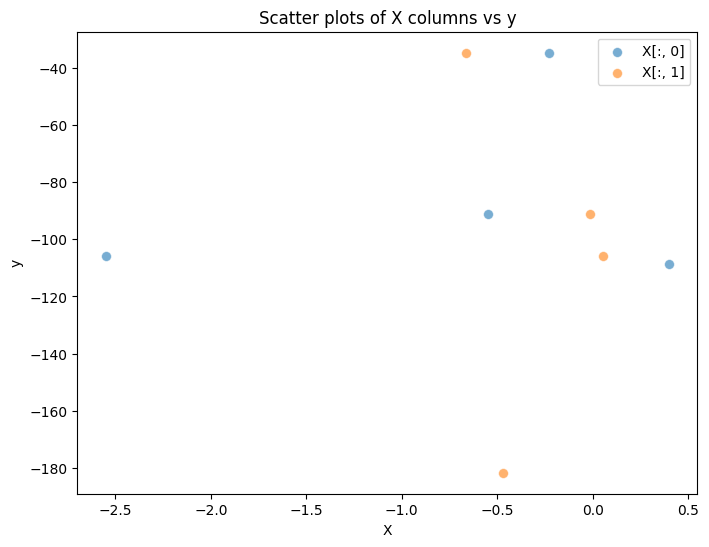

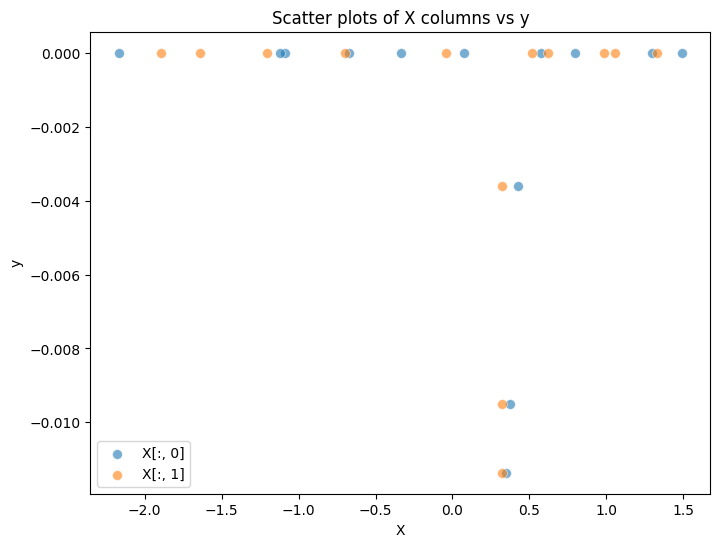

In [169]:
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler

x_scaler = StandardScaler(with_mean=True, with_std=True)
y_scaler = RobustScaler()

x_log = np.log(np.abs(X))
y_log = np.log(np.abs(y)).reshape(-1, 1)

X_transformed = x_scaler.fit_transform(X)
y_transformed = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()

PlotUtils.scatter(x_log, y_log.ravel(), show_min_max=False)
PlotUtils.scatter(np.log(X_transformed), np.log(y_transformed), show_min_max=False)
PlotUtils.scatter(X_transformed, y_transformed, show_min_max=False)


In [36]:

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

# 1. Matern(nu=2.5): The 5/2 kernel we discussed.
# 2. WhiteKernel: This handles "Noise". It tells the model 
#    "The data isn't perfect, allow for some wiggle room."
kernel = Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 10.0), nu=2.5) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-5, 1e1))

model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=100, normalize_y=True)

model.fit(X_transformed, y_transformed)


print("Model Trained.")
print(f"Learned Kernel Parameters: {model.kernel_}")


/workspaces/capstone_imperial_ml_ai/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,kernel,Matern(length...e_level=1e-05)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,100
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,"Matern(length...1, 1], nu=2.5)"
,kernel__k2,WhiteKernel(noise_level=1e-05)
,kernel__k1__length_scale,"[1.0, 1.0]"


Model Trained.
Learned Kernel Parameters: Matern(length_scale=[0.541, 0.348], nu=2.5) + WhiteKernel(noise_level=1e-05)


In [ ]:

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

# 1. Matern(nu=2.5): The 5/2 kernel we discussed.
# 2. WhiteKernel: This handles "Noise". It tells the model 
#    "The data isn't perfect, allow for some wiggle room."
kernel = Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 10.0), nu=2.5) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-5, 1e1))

model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=100, normalize_y=True)

model.fit(X_transformed, y_transformed)


print("Model Trained.")
print(f"Learned Kernel Parameters: {model.kernel_}")


/workspaces/capstone_imperial_ml_ai/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,kernel,Matern(length...e_level=1e-05)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,100
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,"Matern(length...1, 1], nu=2.5)"
,kernel__k2,WhiteKernel(noise_level=1e-05)
,kernel__k1__length_scale,"[1.0, 1.0]"


Model Trained.
Learned Kernel Parameters: Matern(length_scale=[0.541, 0.348], nu=2.5) + WhiteKernel(noise_level=1e-05)


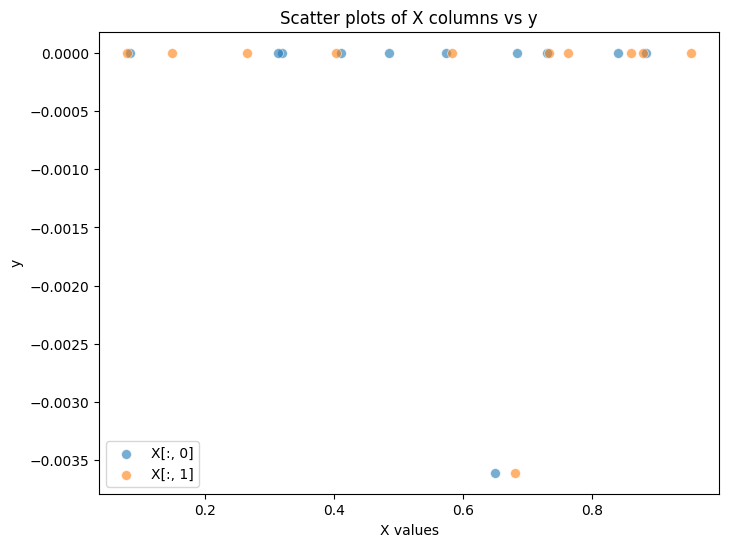

In [37]:
PlotUtils.scatter(X, y)

In [38]:
def predict(X_new):
    X_new_log = np.log(np.abs(X_new))
    X_new_transformed = x_scaler.transform(X_new_log)
    y_pred_transformed, y_std_transformed = model.predict(X_new_transformed, return_std=True)
    y_pred_log = y_scaler.inverse_transform(y_pred_transformed.reshape(-1, 1)).ravel()
    y_pred = -1 * np.exp(y_pred_log)
    return y_pred, y_std_transformed

x_space = np.linspace(0.6, 0.70, 10)
x_space = np.array([[x1, x1] for x1 in x_space])
y_pred, y_std = predict(x_space)
print("Predictions:")
for xi, yi, si in zip(x_space, y_pred, y_std):
    print(f"X: {xi}, Predicted y: {yi}, Std Dev: {si}")

Predictions:
X: [0.6 0.6], Predicted y: -3.664784535203939e-15, Std Dev: 0.3917233745049321
X: [0.61111111 0.61111111], Predicted y: -4.169900729852821e-12, Std Dev: 0.33132196432897026
X: [0.62222222 0.62222222], Predicted y: -1.9596185654646737e-09, Std Dev: 0.270046420254736
X: [0.63333333 0.63333333], Predicted y: -3.019347173077998e-07, Std Dev: 0.21038446376426714
X: [0.64444444 0.64444444], Predicted y: -1.2297589890789692e-05, Std Dev: 0.15590480011073474
X: [0.65555556 0.65555556], Predicted y: -0.00011052347989128152, Std Dev: 0.11187958714260506
X: [0.66666667 0.66666667], Predicted y: -0.00019409481248535264, Std Dev: 0.08506166798369336
X: [0.67777778 0.67777778], Predicted y: -6.428195930670953e-05, Std Dev: 0.0770199308332287
X: [0.68888889 0.68888889], Predicted y: -4.2843683074472846e-06, Std Dev: 0.07672131379393245
X: [0.7 0.7], Predicted y: -6.655986384208632e-08, Std Dev: 0.07182209041621763


In [ ]:


import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize

display(Math(r"EI(x) = \mathbb{E}[\max(0, f(x) - f(x^+))]"))
def expected_improvement(x, model, y_best, xi=0.01):
    """
    Computes the EI at point x based on the GP model.
    """
    # FIX: Reshape to (1, n_features) so sklearn sees 1 sample with N features
    x_2d = x.reshape(1, -1)
    
    # 1. Ask the model for the mean and standard deviation
    mu, sigma = model.predict(x_2d, return_std=True)
    
    # 2. Calculate the improvement logic
    with np.errstate(divide='warn'):
        imp = mu - y_best - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        
        # Handle cases where sigma is 0 (we've already drilled here)
        ei[sigma == 0.0] = 0.0

    return ei

def propose_next_location(model, y_best, bounds, n_restarts=25):
    """
    Finds the x that maximizes Expected Improvement.
    """
    # Ensure bounds are in the right format for the optimizer
    dim = len(bounds)
    min_val = 1
    min_x = None
    
    # Randomly initialize the search N times to avoid local optima
    # We generate random starting points within the bounds for each dimension
    random_starts = np.random.uniform(
        low=[b[0] for b in bounds], 
        high=[b[1] for b in bounds], 
        size=(n_restarts, dim)
    )
    
    for x0 in random_starts:
        res = minimize(lambda x: -expected_improvement(x, model, y_best), 
                       x0=x0, 
                       bounds=bounds, 
                       method='L-BFGS-B')
        
        if res.fun < min_val:
            min_val = res.fun
            min_x = res.x
            
    return min_x.reshape(1, -1)

In [40]:
def get_bounds(X_final):
    """
    Calculate safe bounds for the optimization based on the empirical data.
    Adds a buffer to allow exploration outside the current sampled region.
    """
    # Assuming X_final is your scaled input array (N_samples, N_features)

    # 1. Calculate the empirical min and max for each feature (dimension)
    x_min = np.min(X_final, axis=0)
    x_max = np.max(X_final, axis=0)

    # 2. Add a small buffer (e.g., 25%) for exploration outside the current sampled region
    buffer = 0.25 # Adds 25% extra room on either side

    # 3. Create the final bounds list of tuples
    bounds_list = []
    for i in range(X_final.shape[1]): # Iterate through each feature
        # Calculate the range and buffer size
        feature_range = x_max[i] - x_min[i]
        buffer_size = feature_range * buffer
        
        # Define the new bounds (min - buffer, max + buffer)
        new_min = x_min[i] - buffer_size
        new_max = x_max[i] + buffer_size
        
        bounds_list.append((new_min, new_max))

    # bounds_list is now the correct variable to pass to propose_next_location
    print("Calculated Safe Bounds:", bounds_list)

    return bounds_list



In [41]:
# ... (Assume 'model' is your fitted Gaussian Process from the previous step)
# ... (Assume 'y_final' is your scaled, log-transformed target data)

# 1. Identify the current record holder (in Log Space)
current_best_y = np.max(y)

# 2. Define the bounds of your input space (e.g., 0 to 1)
bounds = [
    (-2., 1.5), # Bounds for Feature 1
    (-2, 1.5)  # Bounds for Feature 2
]
bounds = get_bounds(X_transformed)

# 3. Ask the Acquisition Function where to drill next
next_x_scaled_log = propose_next_location(model, current_best_y, bounds)

print(f"The Mathematical Compass says drill at X (scaled/log): {next_x_scaled_log}")

# 4. UN-TRANSFORM X to get the real coordinates for the competition
# (Assuming you log-scaled X as discussed earlier)
real_next_x = np.exp(x_scaler.inverse_transform(next_x_scaled_log))

print(f"Drill coordinate for submission: {real_next_x.tolist()}")

predicted_y, predicted_std = predict(real_next_x)
print(f"Predicted y at this location: {predicted_y}, with std dev: {predicted_std}")

Calculated Safe Bounds: [(np.float64(-3.603809637456644), np.float64(1.9099951505119503)), (np.float64(-3.0496340166242915), np.float64(1.7239040308595999))]
The Mathematical Compass says drill at X (scaled/log): [[0.48662214 0.49861033]]
Drill coordinate for submission: [[0.638371782454783, 0.6812481476782466]]
Predicted y at this location: [-0.0054263], with std dev: [0.03594]


In [ ]:

test_1, test_std = predict(np.array([[0.484425, 0.954131]]))
print(f"Test Prediction at [0.484425, 0.954131]: {test_1}, Std Dev: {test_std}")

Test Prediction at [0.484425, 0.954131]: [-1.25560587e-88], Std Dev: [0.00366699]


In [30]:
x, y = DataLoader.load_data(function_name="function_1")
print(x, y)

x_s, y_s = DataLoader.load_submission_data(function_name="function_1")
print(x_s, y_s)


np.vstack([x, x_s])
np.hstack([y, y_s])

Loaded data from /workspaces/capstone_imperial_ml_ai/data/initial_data/function_1
Input shape: (10, 2), Output shape: (10,)
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]] [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048]
Loaded submission data from /workspaces/capstone_imperial_ml_ai/data/submissions/function_1.json
Submission input shape: (1, 2), output shape: (1,)
[[0.484425 0.954131]] [1.2527456e-88]


array([[0.31940389, 0.76295937],
       [0.57432921, 0.8798981 ],
       [0.73102363, 0.73299988],
       [0.84035342, 0.26473161],
       [0.65011406, 0.68152635],
       [0.41043714, 0.1475543 ],
       [0.31269116, 0.07872278],
       [0.68341817, 0.86105746],
       [0.08250725, 0.40348751],
       [0.88388983, 0.58225397],
       [0.484425  , 0.954131  ]])

array([ 1.32267704e-079,  1.03307824e-046,  7.71087511e-016,
        3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
       -2.08909327e-091,  2.53500115e-040,  3.60677119e-081,
        6.22985647e-048,  1.25274560e-088])